# QINCo2 compressed-result plots

This notebook scans `/mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res`.

Distance handling:

- true distance relative error is only computed from archive artifacts that contain both exact squared-L2 distances and approximate squared-L2 distances;
- the formula is `abs(||q - xhat||^2 - ||q - x||^2) / max(||q - x||^2, 1e-6)`;
- encoded `codes` alone are not enough to compute ADC distance, because QINCo/QINCo2 reconstruction requires the learned neural decoder;
- validation/train MSE from logs is plotted separately as reconstruction quality, not as ADC relative error.


In [1]:
from __future__ import annotations

import io
import json
import math
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

INPUT_DIR = Path("/mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res")
OUTPUT_DIR = INPUT_DIR / "figures2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_FORMATS = ("pdf", "svg")
DATASETS_TO_PLOT = ["deep", "bigann", "gist", "msmarco", "openai"]

ZIP_RE = re.compile(r"^(?P<dataset>[a-zA-Z0-9_]+)_M_(?P<M>\d+)_K_(?P<K>\d+)\.zip$")
SETTING_RE = re.compile(r"/setting_(\d+)/")
FLOAT = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?|nan|inf|-inf"
VAL_MSE_RE = re.compile(rf"Validation metrics:\s*\[\[MSE=({FLOAT})\]\]|validation MSE=\s*({FLOAT})", re.I)
TRAIN_MSE_RE = re.compile(rf"train(?: set)? MSE=\s*({FLOAT})|mse_loss=({FLOAT})", re.I)
BEST_MSE_RE = re.compile(rf"min_MSE=({FLOAT})", re.I)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.figsize": (9, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = ["tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
MARKERS = ["o", "v", "s", "^", "D", "<", ">", "p", "*", "h"]


In [2]:
def parse_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan


def finite_min(values):
    vals = [v for v in values if np.isfinite(v)]
    return min(vals) if vals else np.nan


def finite_last(values):
    vals = [v for v in values if np.isfinite(v)]
    return vals[-1] if vals else np.nan


def parse_zip_name(path: Path):
    m = ZIP_RE.match(path.name)
    if not m:
        raise ValueError(f"Bad QINCo2 archive name: {path.name}")
    return m.group("dataset"), int(m.group("M")), int(m.group("K"))


def parse_setting_ids(names):
    ids = set()
    for name in names:
        m = SETTING_RE.search(name)
        if m:
            ids.add(int(m.group(1)))
    return sorted(ids) or [0]


def read_json_or_empty(zf, name):
    try:
        with zf.open(name) as f:
            return json.load(f)
    except KeyError:
        return {}


def read_log_or_empty(zf, name):
    try:
        return zf.read(name).decode("utf-8", errors="replace")
    except KeyError:
        return ""


def extract_log_metrics(text):
    val_vals = []
    for m in VAL_MSE_RE.findall(text):
        val_vals.extend(parse_float(v) for v in m if v)
    train_vals = []
    for m in TRAIN_MSE_RE.findall(text):
        train_vals.extend(parse_float(v) for v in m if v)
    best_vals = [parse_float(v) for v in BEST_MSE_RE.findall(text)]
    return {
        "val_mse_best": finite_min(val_vals),
        "train_mse_last": finite_last(train_vals),
        "best_min_mse": finite_min(best_vals),
    }


def distance_relerr_from_npz_bytes(blob):
    data = np.load(io.BytesIO(blob), allow_pickle=False)
    keys = list(data.keys())
    exact_key = next((k for k in keys if "exact" in k.lower() and "dist" in k.lower()), None)
    approx_key = next((k for k in keys if ("approx" in k.lower() or "adc" in k.lower() or "qinco" in k.lower()) and "dist" in k.lower()), None)
    if exact_key is None or approx_key is None:
        return np.nan, np.nan, 0
    exact = np.asarray(data[exact_key], dtype=np.float64)
    approx = np.asarray(data[approx_key], dtype=np.float64)
    if exact.shape != approx.shape:
        return np.nan, np.nan, 0
    rel = np.abs(approx - exact) / np.maximum(exact, 1e-6)
    rel = rel[np.isfinite(rel)]
    if rel.size == 0:
        return np.nan, np.nan, 0
    return float(rel.mean()), float(rel.std()), int(rel.size)


def find_distance_npz(names, setting_id):
    target = f"/setting_{setting_id}/"
    candidates = []
    for name in names:
        low = name.lower()
        if target in name and low.endswith(".npz") and "dist" in low:
            candidates.append(name)
    return sorted(candidates)


def has_npz_kind(names, setting_id, kind):
    target = f"/setting_{setting_id}/"
    return any(target in name and name.endswith(".npz") and kind in name for name in names)


In [3]:
def scan_archives(input_dir: Path = INPUT_DIR):
    rows = []
    zips = sorted(input_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No QINCo2 zip archives found in {input_dir}")

    for zip_path in zips:
        dataset, M, K = parse_zip_name(zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            names = zf.namelist()
            for sid in parse_setting_ids(names):
                base = f"{zip_path.stem}/setting_{sid}"
                conf = read_json_or_empty(zf, f"{base}/conf_0.json")
                enc_conf = read_json_or_empty(zf, f"{base}/encode_test/setting_0/conf_0.json")
                train_enc_conf = read_json_or_empty(zf, f"{base}/encode_train/setting_0/conf_0.json")
                log_text = read_log_or_empty(zf, f"{base}/run.log")
                log_metrics = extract_log_metrics(log_text)

                dist_names = find_distance_npz(names, sid)
                dist_mean = np.nan
                dist_std = np.nan
                dist_count = 0
                dist_source = ""
                for dist_name in dist_names:
                    try:
                        mean, std, count = distance_relerr_from_npz_bytes(zf.read(dist_name))
                    except Exception:
                        mean, std, count = np.nan, np.nan, 0
                    if np.isfinite(mean):
                        dist_mean, dist_std, dist_count = mean, std, count
                        dist_source = dist_name
                        break

                nbits = math.log2(K)
                rows.append({
                    "zip_path": str(zip_path),
                    "zip_size_mb": zip_path.stat().st_size / 1e6,
                    "dataset": dataset,
                    "M": M,
                    "K": K,
                    "nbits": nbits,
                    "bits_per_vector": M * nbits,
                    "setting_id": sid,
                    "A": conf.get("A"),
                    "B": conf.get("B"),
                    "L": conf.get("L"),
                    "de": conf.get("de"),
                    "dh": conf.get("dh"),
                    "ds_loop": conf.get("ds_loop"),
                    "max_epochs": conf.get("max_epochs"),
                    "lr": conf.get("lr"),
                    "encode_tgt_epochs": enc_conf.get("encode_tgt_epochs", train_enc_conf.get("encode_tgt_epochs")),
                    "train_A": enc_conf.get("train_A", train_enc_conf.get("train_A")),
                    "train_B": enc_conf.get("train_B", train_enc_conf.get("train_B")),
                    "has_encode_test_codes": has_npz_kind(names, sid, "encode_test"),
                    "has_encode_train_codes": has_npz_kind(names, sid, "encode_train"),
                    "has_distance_npz": bool(dist_names),
                    "distance_relerr_mean": dist_mean,
                    "distance_relerr_std": dist_std,
                    "distance_relerr_count": dist_count,
                    "distance_source": dist_source,
                    **log_metrics,
                })

    df = pd.DataFrame(rows)
    for col in ["M", "K", "nbits", "bits_per_vector", "A", "B", "L", "de", "dh", "ds_loop", "max_epochs", "lr", "encode_tgt_epochs", "train_A", "train_B", "val_mse_best", "train_mse_last", "best_min_mse", "distance_relerr_mean", "distance_relerr_std"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


manifest_df = scan_archives(INPUT_DIR)
manifest_path = OUTPUT_DIR / "qinco2_compressed_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)
print(f"Scanned {len(manifest_df)} settings from {manifest_df['zip_path'].nunique()} archives")
print(f"Manifest: {manifest_path}")
display(manifest_df.groupby("dataset").agg(settings=("setting_id", "count"), encoded_test=("has_encode_test_codes", "sum"), distance_npz=("has_distance_npz", "sum"), true_relerr=("distance_relerr_mean", lambda s: int(np.isfinite(s).sum()))))


Scanned 242 settings from 217 archives
Manifest: /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_compressed_manifest.csv


,settings,encoded_test,distance_npz,true_relerr
dataset,,,,
bigann,47,40.0,True,1.0
deep,45,40.0,False,0.0
gist,50,35.0,False,0.0
msmarco,50,35.0,False,0.0
openai,50,30.0,False,0.0


In [4]:
metric_rows = []
for _, row in manifest_df.iterrows():
    common = {
        "dataset": row["dataset"],
        "M": row["M"],
        "K": row["K"],
        "nbits": row["nbits"],
        "bits_per_vector": row["bits_per_vector"],
        "setting_id": row["setting_id"],
        "A": row["A"],
        "B": row["B"],
        "L": row["L"],
        "de": row["de"],
        "dh": row["dh"],
        "zip_path": row["zip_path"],
    }
    if np.isfinite(row["distance_relerr_mean"]):
        metric_rows.append({**common, "metric_type": "distance_relerr", "metric_value": row["distance_relerr_mean"], "metric_std": row["distance_relerr_std"]})
    mse = row["best_min_mse"] if np.isfinite(row["best_min_mse"]) else row["val_mse_best"]
    if np.isfinite(mse):
        metric_rows.append({**common, "metric_type": "reconstruction_mse", "metric_value": mse, "metric_std": np.nan})
    if np.isfinite(row["train_mse_last"]):
        metric_rows.append({**common, "metric_type": "train_mse_last", "metric_value": row["train_mse_last"], "metric_std": np.nan})

metrics_df = pd.DataFrame(metric_rows)
metrics_path = OUTPUT_DIR / "qinco2_compressed_metrics_long.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics: {metrics_path}")
display(metrics_df.groupby(["dataset", "metric_type"]).size().unstack(fill_value=0) if not metrics_df.empty else metrics_df)


Metrics: /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_compressed_metrics_long.csv


metric_type,distance_relerr,reconstruction_mse,train_mse_last
dataset,,,
bigann,1,45,45
deep,0,45,45
gist,0,50,50
msmarco,0,50,50
openai,0,50,50


In [5]:
def savefig(fig, stem):
    saved = []
    for ext in FIGURE_FORMATS:
        path = OUTPUT_DIR / f"{stem}.{ext}"
        fig.savefig(path, bbox_inches="tight")
        saved.append(path)
    print("Saved " + " and ".join(str(p) for p in saved))


def style_axis(ax, x_integer=False, max_xticks=4):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.3)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=x_integer))


def plot_metric_vs_bpv(metric_type, ylabel, stem_prefix, datasets=DATASETS_TO_PLOT):
    sub_all = metrics_df[metrics_df["metric_type"] == metric_type].copy()
    if sub_all.empty:
        print(f"No rows for {metric_type}")
        return
    for dataset in datasets:
        sub = sub_all[sub_all["dataset"] == dataset].dropna(subset=["bits_per_vector", "metric_value"])
        if sub.empty:
            print(f"Skipping {dataset}: no {metric_type}")
            continue
        fig, ax = plt.subplots()
        for i, (K, g) in enumerate(sorted(sub.groupby("K"), key=lambda kv: kv[0])):
            g = g.sort_values(["bits_per_vector", "metric_value"])
            ax.plot(
                g["bits_per_vector"], g["metric_value"],
                marker=MARKERS[i % len(MARKERS)],
                color=COLORS[i % len(COLORS)],
                linewidth=2,
                markersize=8,
                markeredgecolor="black",
                markeredgewidth=0.8,
                label=f"K={int(K)}",
            )
        ax.set_title(dataset)
        ax.set_xlabel("bits per vector")
        ax.set_ylabel(ylabel)
        style_axis(ax, x_integer=True, max_xticks=3)
        if sub["K"].nunique() > 1:
            ax.legend(frameon=False, bbox_to_anchor=(1.02, 0.5), loc="center left")
        savefig(fig, f"{stem_prefix}_vs_bits_per_vector_{dataset}")


def plot_metric_vs_M(metric_type, ylabel, stem_prefix, datasets=DATASETS_TO_PLOT):
    sub_all = metrics_df[metrics_df["metric_type"] == metric_type].copy()
    if sub_all.empty:
        print(f"No rows for {metric_type}")
        return
    for dataset in datasets:
        sub = sub_all[sub_all["dataset"] == dataset].dropna(subset=["M", "metric_value"])
        if sub.empty:
            print(f"Skipping {dataset}: no {metric_type}")
            continue
        fig, ax = plt.subplots()
        for i, (K, g) in enumerate(sorted(sub.groupby("K"), key=lambda kv: kv[0])):
            g = g.sort_values(["M", "metric_value"])
            ax.plot(
                g["M"], g["metric_value"],
                marker=MARKERS[i % len(MARKERS)],
                color=COLORS[i % len(COLORS)],
                linewidth=2,
                markersize=8,
                markeredgecolor="black",
                markeredgewidth=0.8,
                label=f"K={int(K)}",
            )
        ax.set_title(dataset)
        ax.set_xlabel("M")
        ax.set_ylabel(ylabel)
        style_axis(ax, x_integer=True, max_xticks=4)
        if sub["K"].nunique() > 1:
            ax.legend(frameon=False, bbox_to_anchor=(1.02, 0.5), loc="center left")
        savefig(fig, f"{stem_prefix}_vs_M_{dataset}")


Skipping deep: no distance_relerr
Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_true_distance_relerr_vs_bits_per_vector_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_true_distance_relerr_vs_bits_per_vector_bigann.svg
Skipping gist: no distance_relerr
Skipping msmarco: no distance_relerr
Skipping openai: no distance_relerr
Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_vs_bits_per_vector_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_vs_bits_per_vector_deep.svg
Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_vs_bits_per_vector_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figure

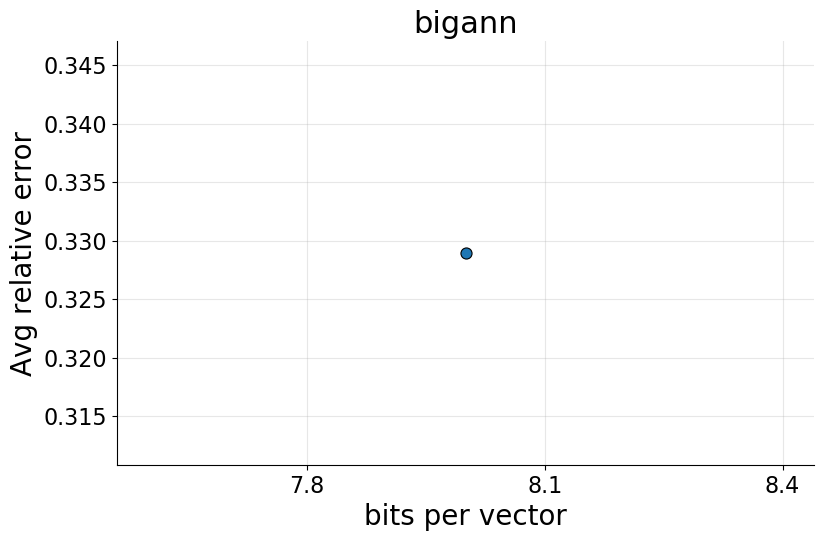

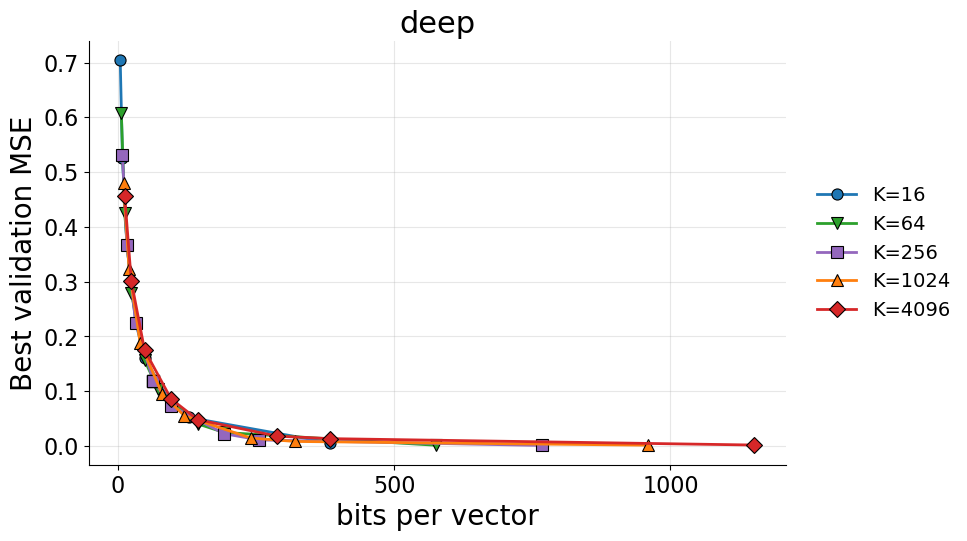

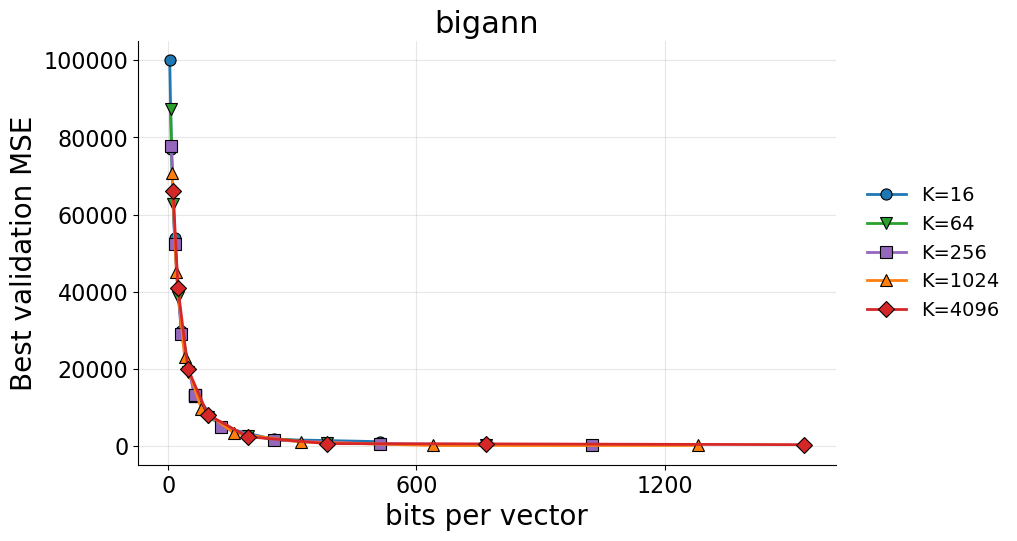

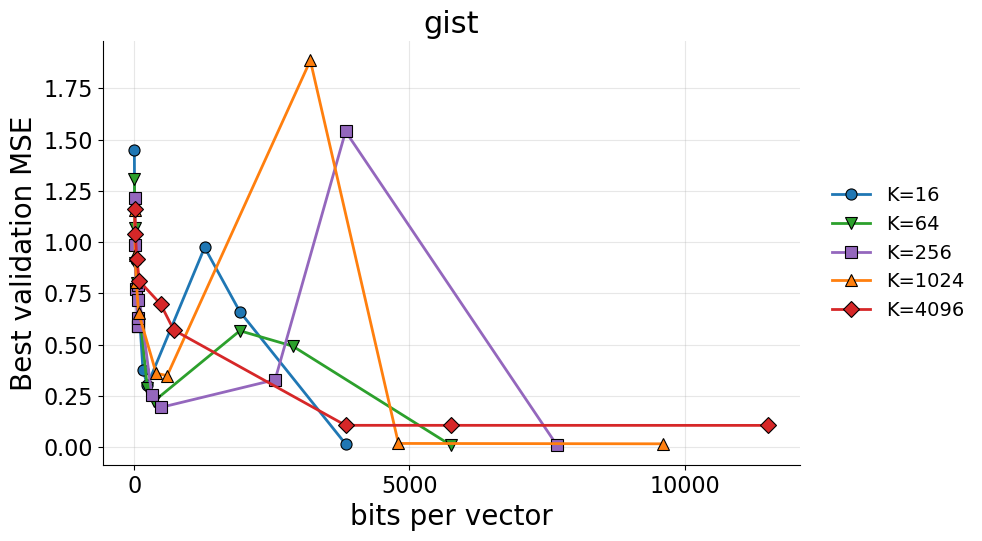

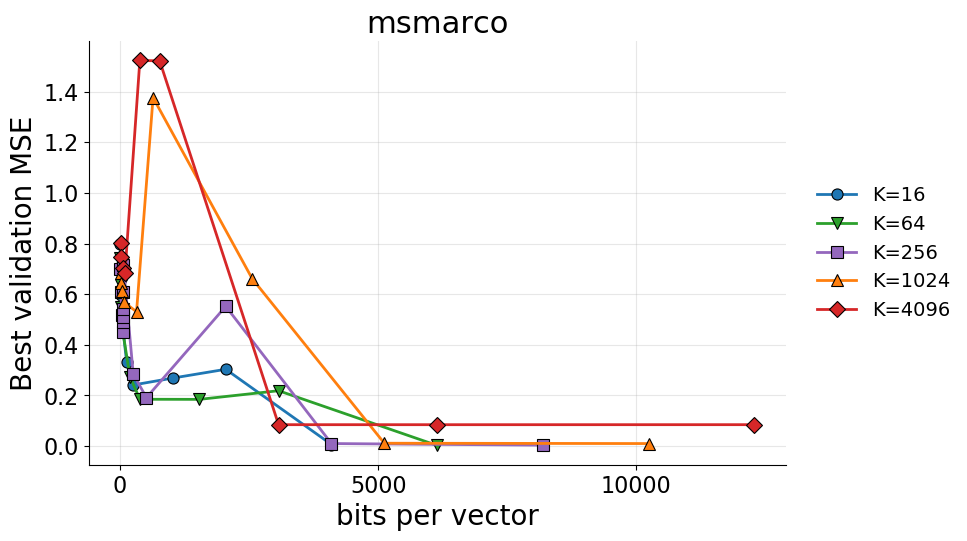

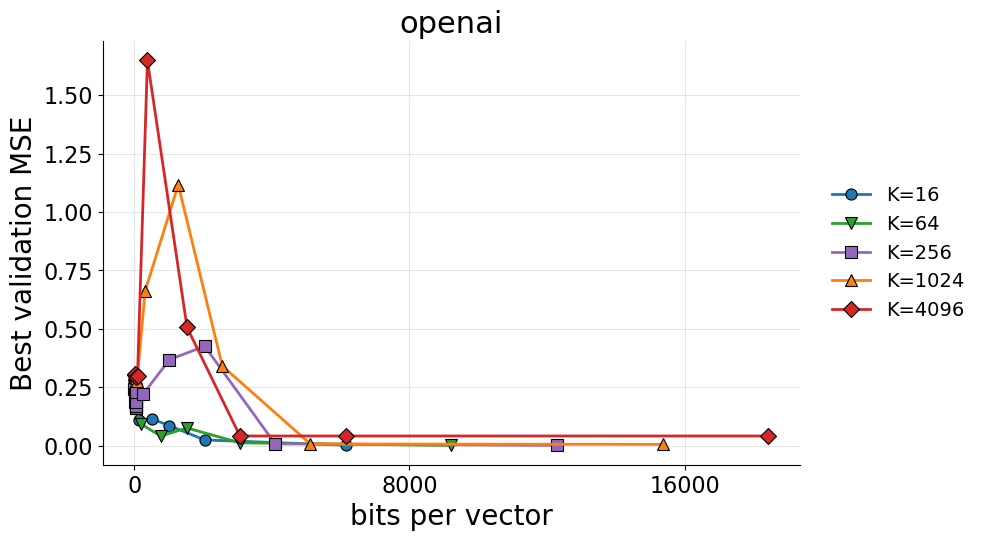

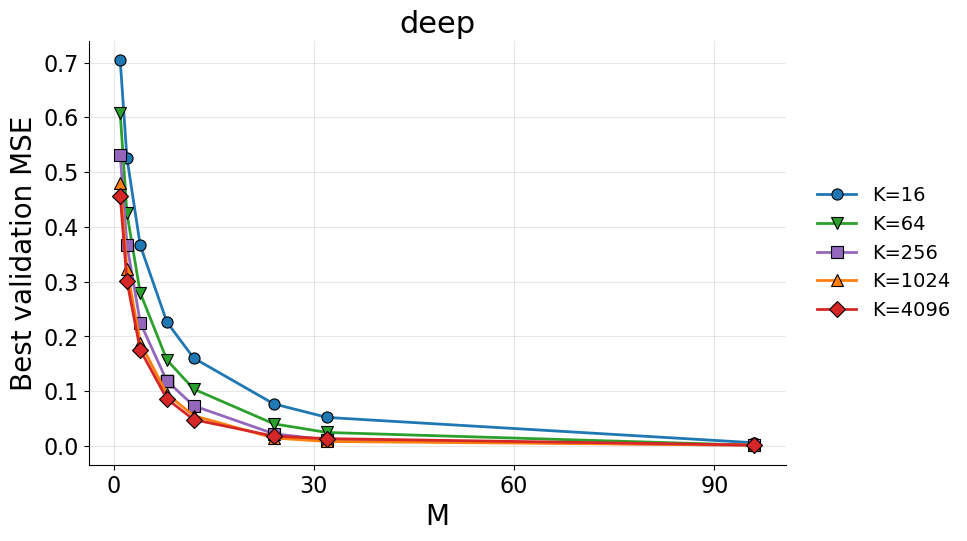

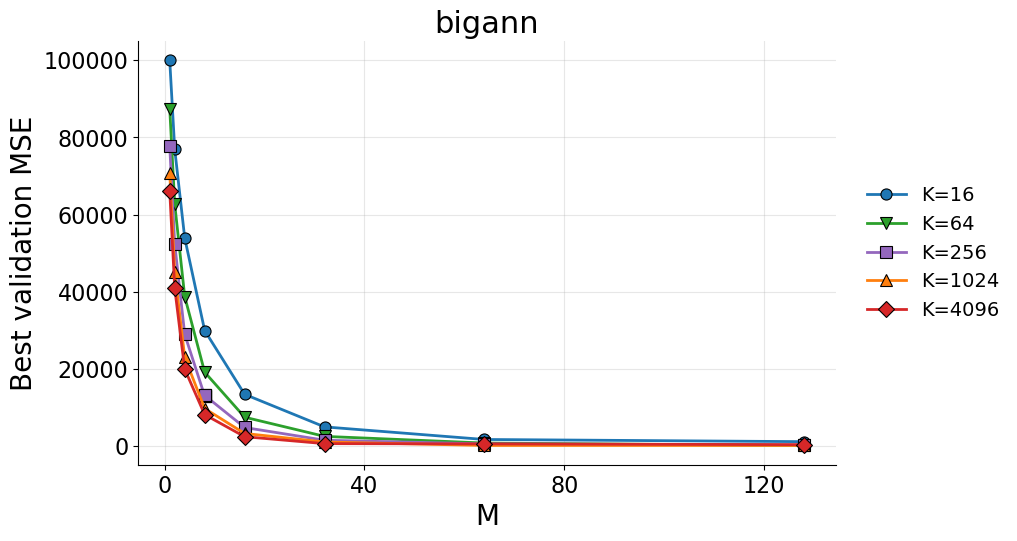

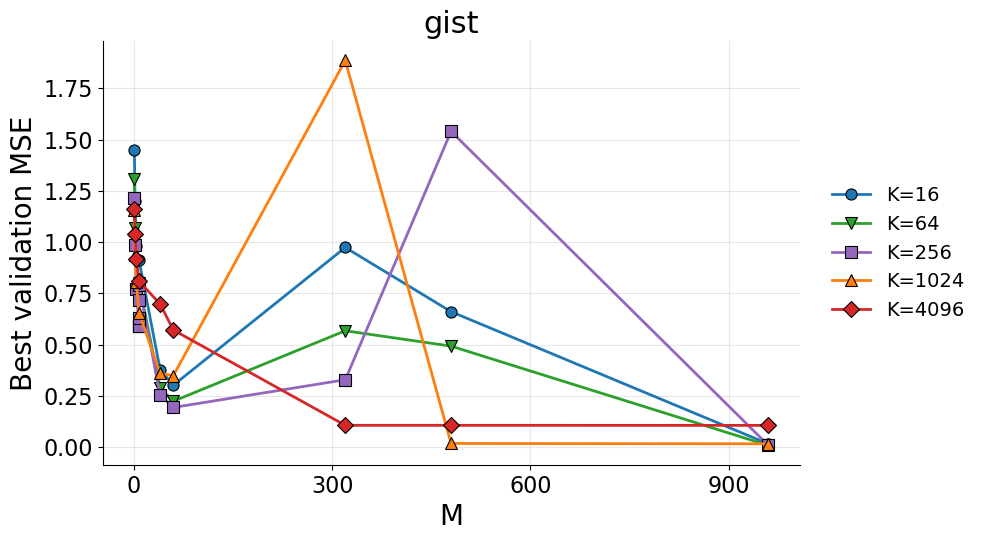

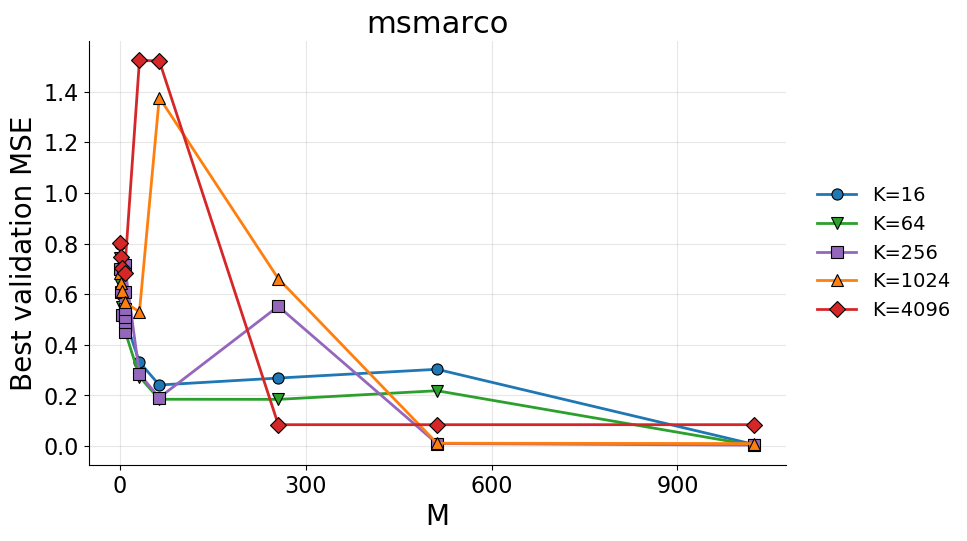

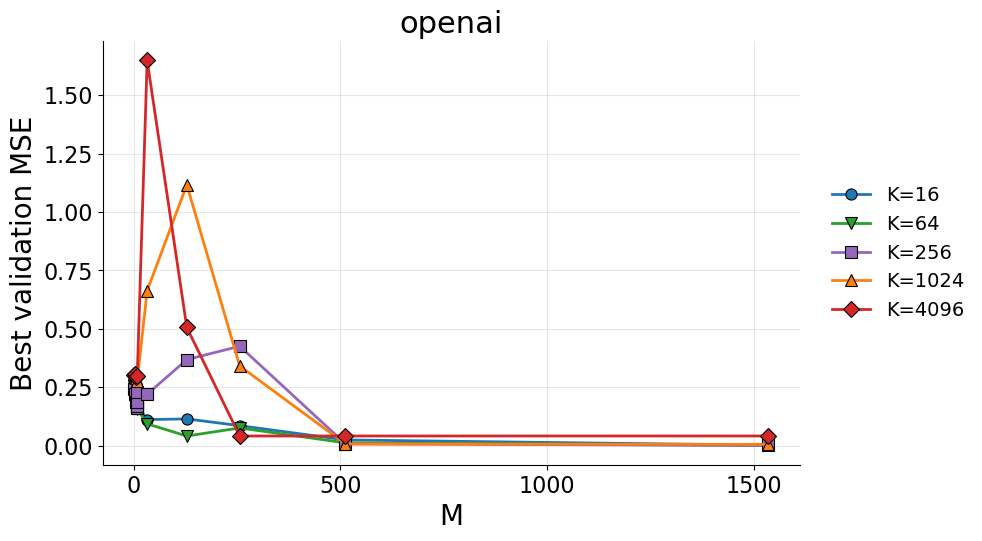

In [6]:
plot_metric_vs_bpv(
    metric_type="distance_relerr",
    ylabel="Avg relative error",
    stem_prefix="qinco2_true_distance_relerr",
)

plot_metric_vs_bpv(
    metric_type="reconstruction_mse",
    ylabel="Best validation MSE",
    stem_prefix="qinco2_reconstruction_mse",
)

plot_metric_vs_M(
    metric_type="reconstruction_mse",
    ylabel="Best validation MSE",
    stem_prefix="qinco2_reconstruction_mse",
)


Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_heatmap_M_by_K_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_heatmap_M_by_K_deep.svg
Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_heatmap_M_by_K_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_heatmap_M_by_K_bigann.svg
Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_heatmap_M_by_K_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstruction_mse_heatmap_M_by_K_gist.svg
Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/qinco2/compressed_qinco_res/figures2/qinco2_reconstru

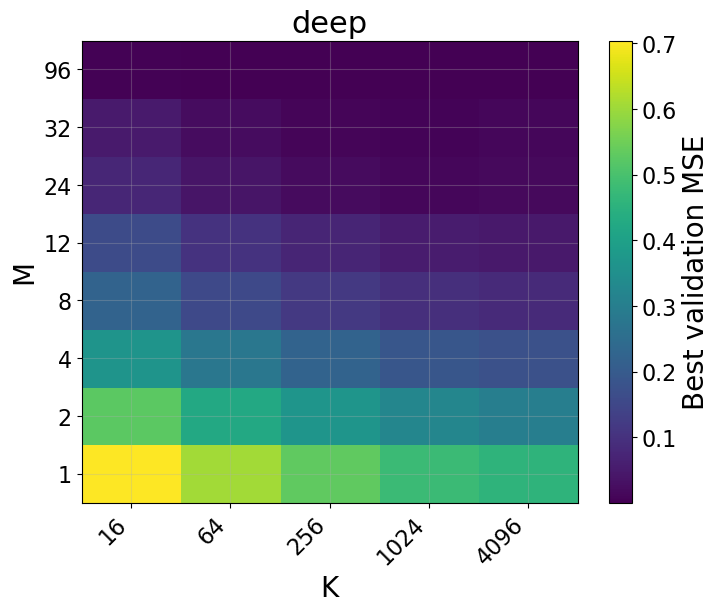

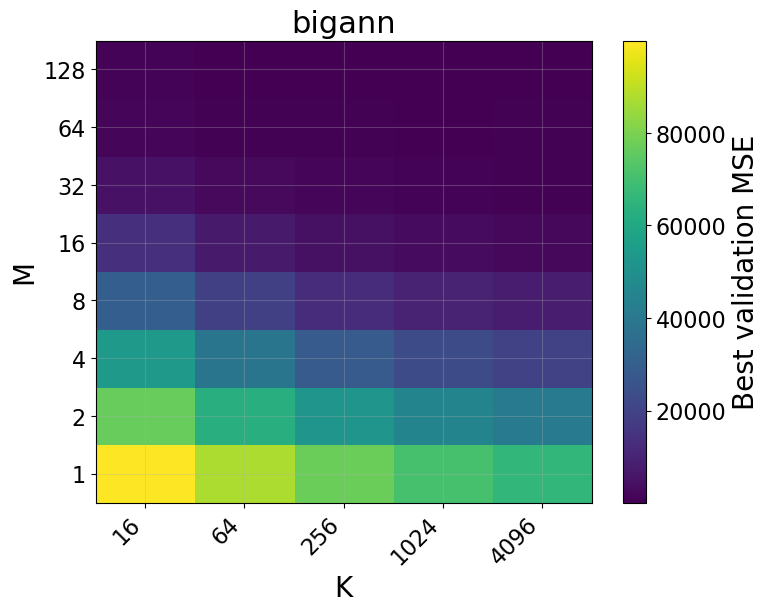

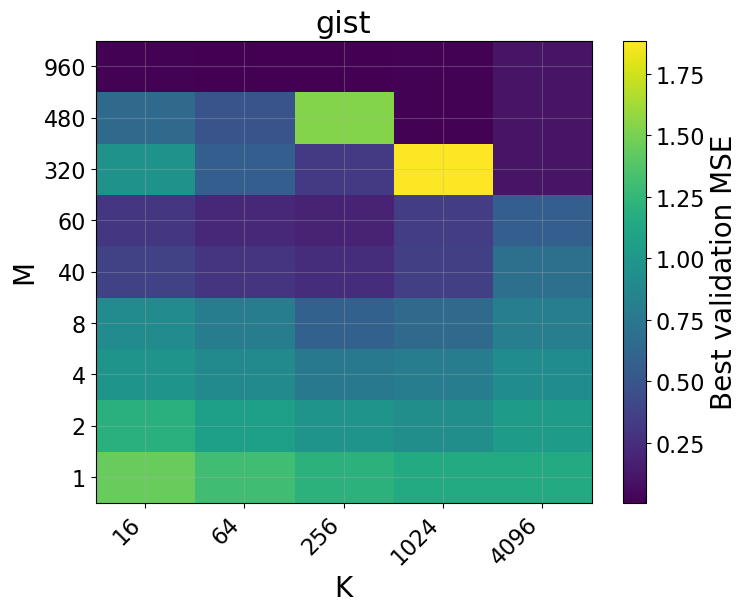

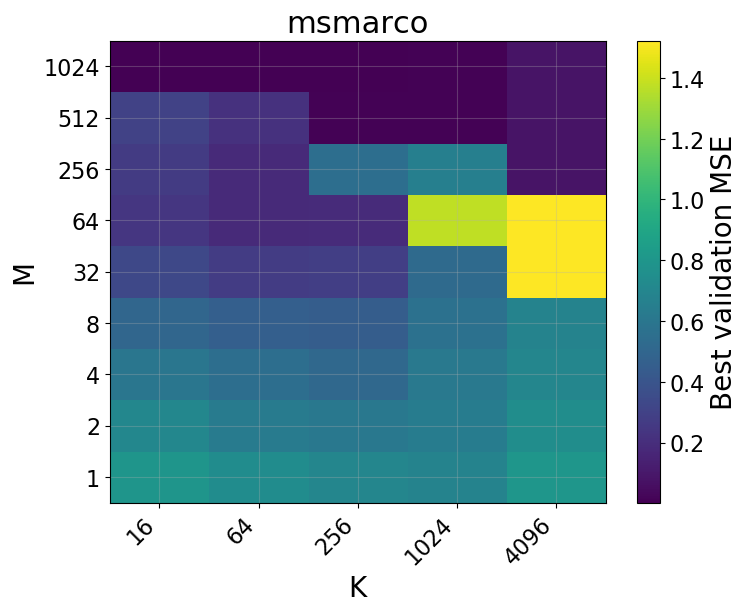

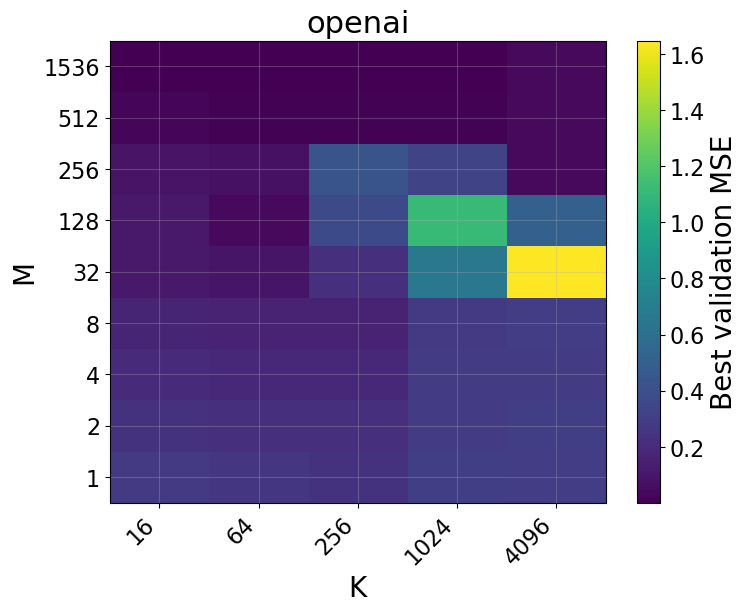

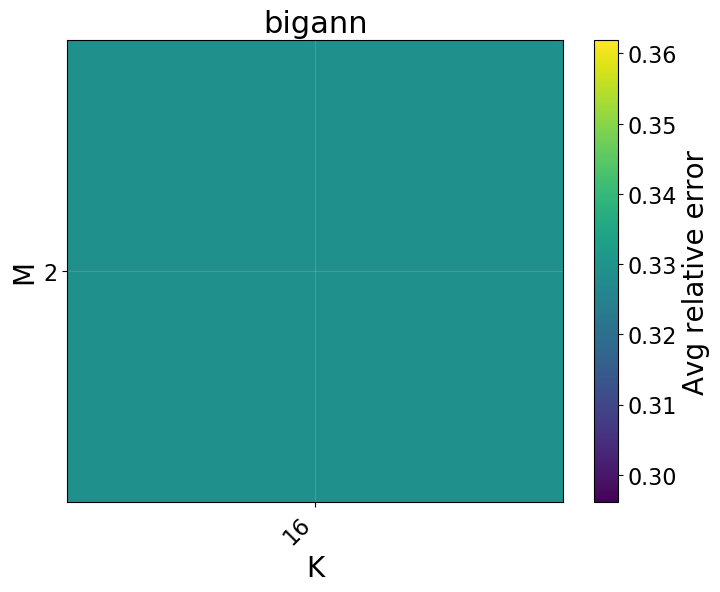

In [7]:
def plot_heatmaps(metric_type="reconstruction_mse", ylabel="Best validation MSE", datasets=DATASETS_TO_PLOT):
    sub_all = metrics_df[metrics_df["metric_type"] == metric_type].copy()
    if sub_all.empty:
        print(f"No rows for {metric_type}")
        return
    for dataset in datasets:
        sub = sub_all[sub_all["dataset"] == dataset].dropna(subset=["M", "K", "metric_value"])
        if sub.empty:
            print(f"Skipping {dataset}: no heatmap rows")
            continue
        pivot = sub.pivot_table(index="M", columns="K", values="metric_value", aggfunc="min").sort_index().sort_index(axis=1)
        fig, ax = plt.subplots(figsize=(8, 6))
        masked = np.ma.masked_invalid(pivot.to_numpy(dtype=float))
        im = ax.imshow(masked, aspect="auto", origin="lower", cmap="viridis")
        ax.set_title(dataset)
        ax.set_xlabel("K")
        ax.set_ylabel("M")
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([str(int(v)) for v in pivot.columns], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([str(int(v)) for v in pivot.index])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(ylabel)
        savefig(fig, f"qinco2_{metric_type}_heatmap_M_by_K_{dataset}")


plot_heatmaps("reconstruction_mse", "Best validation MSE")
plot_heatmaps("distance_relerr", "Avg relative error")


In [8]:
best_metric = "distance_relerr" if (metrics_df["metric_type"].eq("distance_relerr").any()) else "reconstruction_mse"
best_df = (
    metrics_df[metrics_df["metric_type"] == best_metric]
    .sort_values(["dataset", "metric_value", "bits_per_vector"])
    .groupby("dataset", as_index=False)
    .first()
)
print(f"Best configurations by {best_metric}:")
display(best_df[["dataset", "metric_value", "bits_per_vector", "M", "K", "A", "B", "L", "de", "dh", "zip_path"]])
best_df.to_csv(OUTPUT_DIR / f"qinco2_best_configs_by_{best_metric}.csv", index=False)


Best configurations by distance_relerr:


,dataset,metric_value,bits_per_vector,M,K,A,B,L,de,dh,zip_path
0,bigann,0.328954,8.0,2,16,16.0,16.0,16.0,384.0,384.0,/mnthdd/cpanourg/2-hdvc/results/urania_results...


## Notes

If the true distance-relative-error section prints no rows, the compressed archives do not include enough information to calculate ADC-style relative error by themselves. In that case we need either:

- a distance NPZ with exact squared-L2 distances and QINCo/QINCo2 approximate squared-L2 distances, or
- the trained model/checkpoint plus the database/query vectors so we can decode `codes` into `xhat` and then compute `cdist(query, xhat, metric="sqeuclidean")`.
